# Single-pulsar outlier detection (Wang & Taylor 2022)

Walkthrough of `discovery.models.nanograv_single_pulsar_outlier` on J0437-4715 from the NANOGrav 20-yr release. The 20-yr data still contains outlier TOAs; the 15-yr release has been scrubbed.

For the statistical model and design see [the design doc](../src/discovery/models/nanograv_single_pulsar_outlier.md).

In [1]:
import json
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import jax
jax.config.update('jax_enable_x64', True)

import discovery as ds
from discovery.models.nanograv_single_pulsar_outlier import (
    make_outlier_likelihood,
    run_outlier_mcmc,
    _partition_params,
)

/Users/pmeyers/miniforge3/envs/disc_tutorial_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

The 20-yr feather and matching noise dictionary live at the project root (one level above `discovery_latest/`). Adjust the path if your layout is different.

In [2]:
DATA = pathlib.Path(ds.__path__[0]) / '../../data'
psr = ds.Pulsar.read_feather(str(DATA / 'v1p1_de440_pint_bipm2019-J1909-3744.feather'))
noisedict = psr.noisedict

# 20-yr Fourier span so red-noise bins match a future PTA-wide analysis.
Tspan = 16 * 86400 * 365.25 # 20 * 86400 * 365.25
print(f'{psr.name}: {psr.residuals.size} TOAs')

J1909-3744: 35037 TOAs


In [3]:
ds.getspan([psr]) / 86400 / 365.25

np.float64(15.492382830511279)

## The model

For each TOA the white-noise variance is rescaled as `alpha_i^{z_i} * sigma_i^2(theta_w)`. Inliers have `z_i = 0` (no rescaling); outliers have `z_i = 1` (variance inflated by per-TOA `alpha_i`).

`run_outlier_mcmc` builds the `PulsarLikelihood`, the numpyro model, and the Gibbs kernel; runs HMCGibbs; and returns an `OutlierFitResult` with convenience accessors. On a laptop a 100-warmup / 100-sample run takes a few minutes; bump warmup + samples on real hardware.

In [4]:
result = run_outlier_mcmc(
    psr,
    rng_key=jax.random.key(1234),
    num_warmup=200,
    num_samples=200,
    max_tree_depth=5, 
    Tspan=Tspan,
)

sample: 100%|██████████| 400/400 [1:10:18<00:00, 10.55s/it, 15 steps of size 2.55e-01. acc. prob=0.75]


## Identifying outliers

For each TOA, the chain-average of `z_i` is the posterior probability that the TOA is an outlier. Wang & Taylor flag anything above 0.1 as suspicious.

0 of 35037 TOAs flagged as outliers


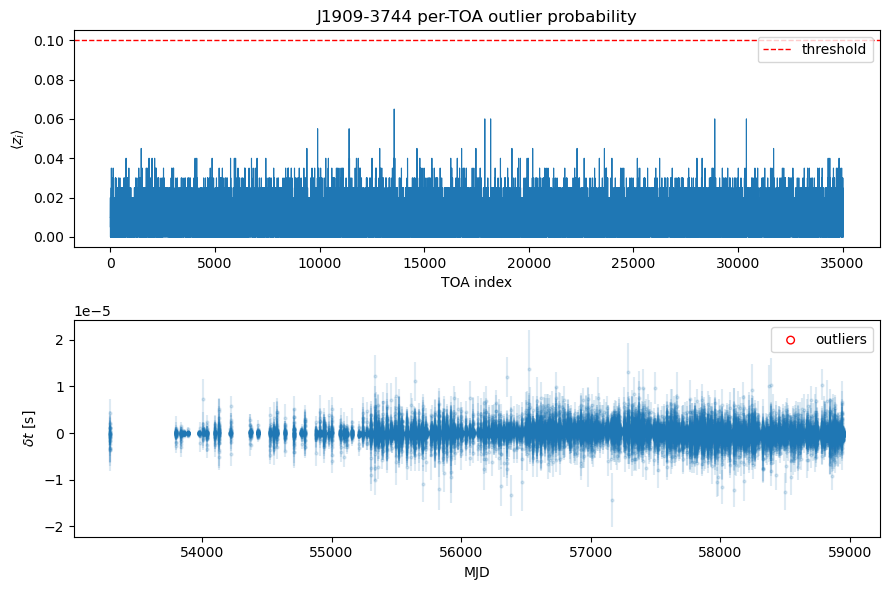

In [5]:
mask = result.outlier_mask(threshold=0.1)
z_mean = np.mean(np.asarray(result.samples['z_i']), axis=0)
print(f'{mask.sum()} of {mask.size} TOAs flagged as outliers')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

ax1.plot(z_mean, lw=0.8)
ax1.axhline(0.1, c='r', ls='--', lw=1, label='threshold')
ax1.set_xlabel('TOA index')
ax1.set_ylabel(r'$\langle z_i \rangle$')
ax1.set_title(f'{psr.name} per-TOA outlier probability')
ax1.legend()

ax2.errorbar(psr.toas / 86400, psr.residuals, yerr=psr.toaerrs,
             alpha=0.15, fmt='o', markersize=2)
ax2.scatter(psr.toas[mask] / 86400, psr.residuals[mask],
            facecolor='none', edgecolor='r', s=30, label='outliers')
ax2.set_xlabel('MJD')
ax2.set_ylabel(r'$\delta t$ [s]')
ax2.legend()
plt.tight_layout()
plt.show()

## Posterior white-noise hyperparameters

Compare the posterior distributions against the values in the official noise dictionary (vertical dashed line). Outlier rejection nudges the estimates relative to a noisedict that was fit assuming no outliers.

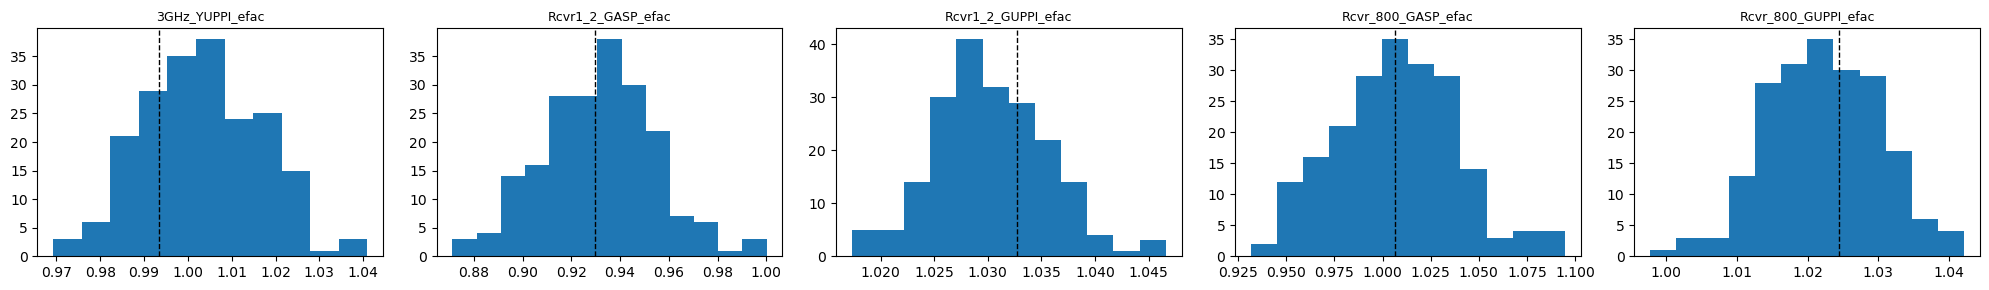

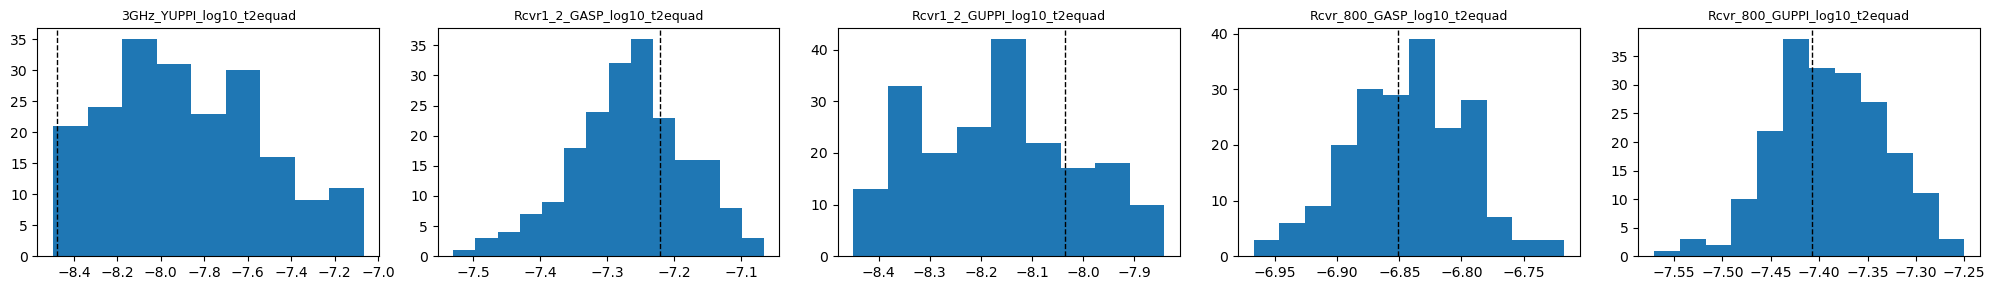

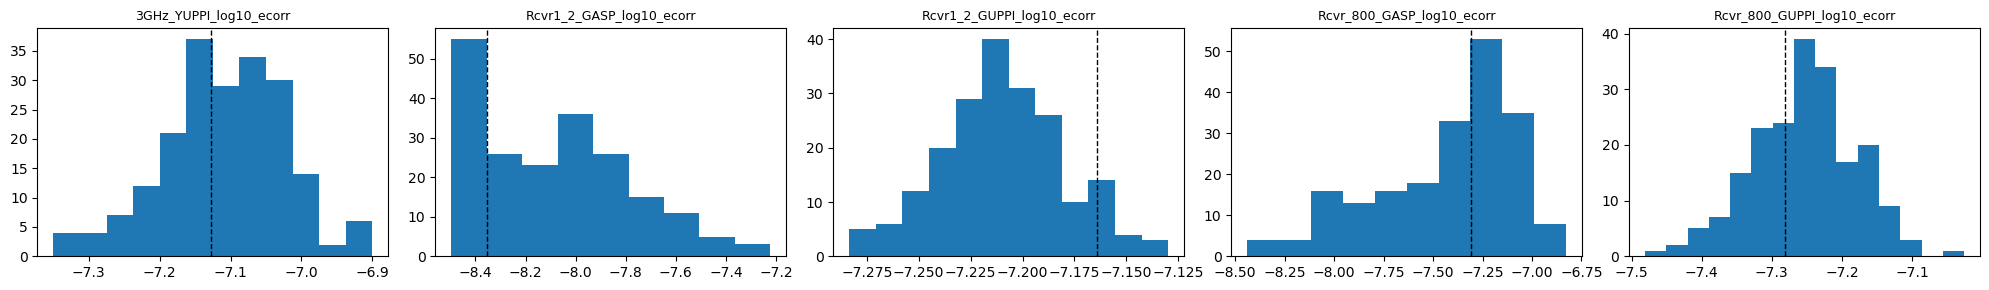

In [6]:
parts = _partition_params(result.psrl)
samples = result.samples

for group, names in [('efacs', parts['efac']),
                     ('equads', parts['equad']),
                     ('ecorrs', parts['ecorr'])]:
    n = len(names)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, i, name in zip(axes, range(n), names):
        ax.hist(samples[group][:, i], bins='auto')
        if name in noisedict:
            ax.axvline(noisedict[name], c='k', ls='--', lw=1)
        ax.set_title(name.split('_', 1)[1], fontsize=9)
    plt.tight_layout()
    plt.show()

## Whitened residuals

After subtracting the conditional-mean GP component and dividing by the unscaled white-noise sigma, inlier TOAs should be approximately $\mathcal{N}(0, 1)$. The histograms below overlay the result for several posterior samples (inliers only); deviations from the red curve indicate residual mis-modeling.

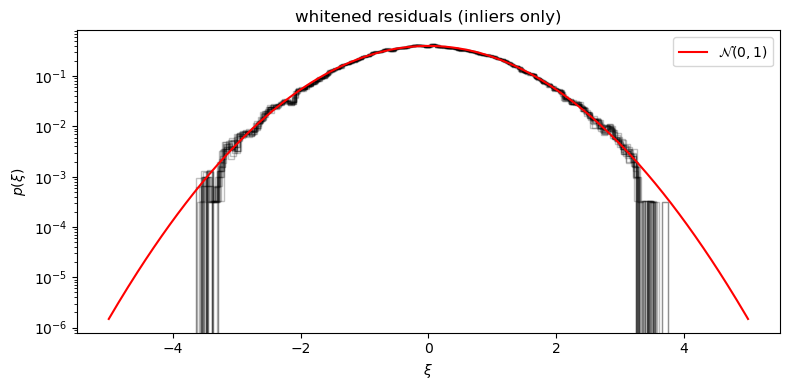

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(0, len(samples['z_i']), 10):
    wr = result.whitened_residuals(sample_idx=i)
    ax.hist(wr[~mask], bins=80, density=True, histtype='step',
            alpha=0.25, color='k')

xs = np.linspace(-5, 5, 400)
ax.plot(xs, norm.pdf(xs), c='r', lw=1.5, label=r'$\mathcal{N}(0,1)$')
ax.set_yscale('log')
ax.set_xlabel(r'$\xi$')
ax.set_ylabel(r'$p(\xi)$')
ax.set_title('whitened residuals (inliers only)')
ax.legend()
plt.tight_layout()
plt.show()